# NLP Project 12: YouTube Comment Analysis

**Kaggle Dataset:** 100K YouTube Comments – YouTube Sentiment Dataset

The dataset contains 100,000 YouTube comments labeled Positive or Negative.

**Tasks:** collect YouTube comment data, preprocess comment text, perform sentiment analysis, identify viewer interests, and visualize audience reactions.

In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return " ".join(
        LEMMATIZER.lemmatize(w) for w in text.split()
        if w not in STOP_WORDS and len(w) > 2
    )

def evaluate_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    pre = precision_score(y_test, pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, pred, average="weighted", zero_division=0)
    print(f"{name} Accuracy: {acc*100:.2f}%")
    print(f"Weighted Precision: {pre*100:.2f}%")
    print(f"Weighted Recall: {rec*100:.2f}%")
    print(f"Weighted F1: {f1*100:.2f}%")
    print(classification_report(y_test, pred, zero_division=0))
    return pred, acc, pre, rec, f1


## 1. Download Dataset

In [2]:
path = kagglehub.dataset_download("surajbhandari527/100k-youtube-comments-youtube-sentiment-dataset")
print("Dataset path:", path)
for root, dirs, files in os.walk(path):
    if files: print(root, files[:10])

Using Colab cache for faster access to the '100k-youtube-comments-youtube-sentiment-dataset' dataset.
Dataset path: /kaggle/input/100k-youtube-comments-youtube-sentiment-dataset
/kaggle/input/100k-youtube-comments-youtube-sentiment-dataset ['100000 Youtube comments sentiment dataset.csv', '.nfs000000003210954100000002']


## 2. Load Dataset

In [3]:
csv_files = []
for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith(".csv"):
            csv_files.append(os.path.join(root,f))
print(csv_files)
csv_file = max(csv_files, key=os.path.getsize)
df = pd.read_csv(csv_file)
print("Shape:", df.shape)
display(df.head())

['/kaggle/input/100k-youtube-comments-youtube-sentiment-dataset/100000 Youtube comments sentiment dataset.csv']
Shape: (116465, 2)


,Comment,Sentiment
0,New fear of elevators unlocked 😖,Negative
1,My heart stopped when he almost dropped the iP...,Negative
2,That glass brige prank is dangerous. Could mak...,Negative
3,bro was falling exactly like they fall in movi...,Positive
4,The smashing glass looks kind of cruel though....,Negative


## 3. Inspect and Clean

In [4]:
print(df.columns.tolist())
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

df.columns = [c.strip().lower().replace(" ","_") for c in df.columns]
df = df.dropna(subset=["comment","sentiment"]).drop_duplicates(subset=["comment","sentiment"])
df["sentiment"] = df["sentiment"].astype(str).str.strip().str.title()
print("Clean shape:", df.shape)
print(df["sentiment"].value_counts())

['Comment', 'Sentiment']
Comment      44
Sentiment     0
dtype: int64
Duplicates: 93613
Clean shape: (22849, 2)
sentiment
Positive    13859
Neutral      4503
Negative     4487
Name: count, dtype: int64


## 4. Visualize Audience Reactions

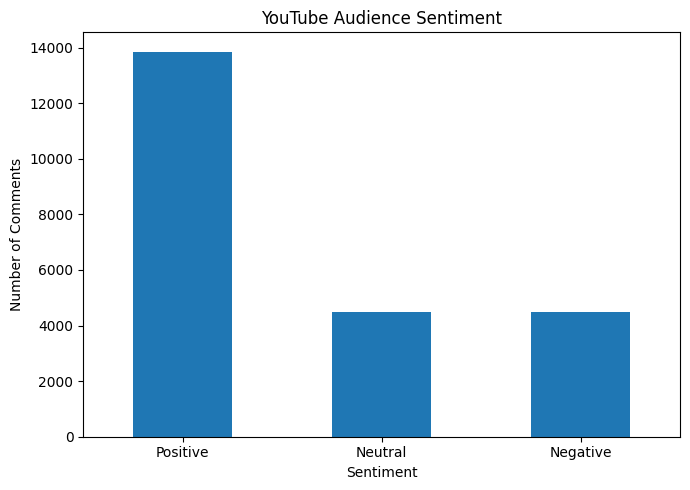

In [5]:
counts = df["sentiment"].value_counts()
plt.figure(figsize=(7,5))
counts.plot(kind="bar")
plt.title("YouTube Audience Sentiment")
plt.xlabel("Sentiment"); plt.ylabel("Number of Comments")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

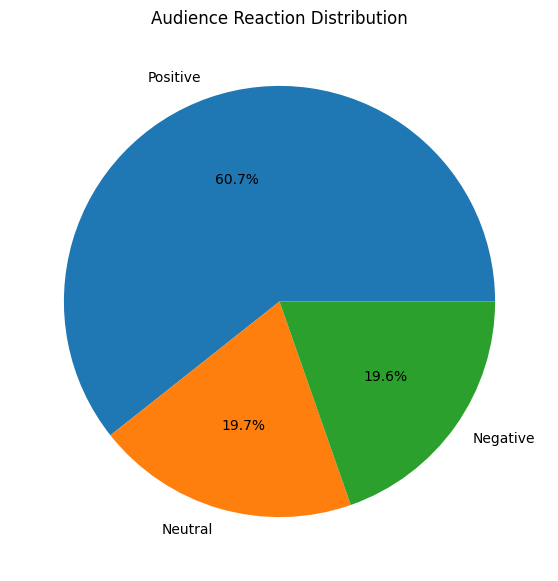

In [6]:
plt.figure(figsize=(7,7))
plt.pie(counts.values, labels=counts.index, autopct="%1.1f%%")
plt.title("Audience Reaction Distribution")
plt.show()

## 5. Preprocess Comment Text

In [7]:
df["clean_comment"] = df["comment"].apply(preprocess_text)
display(df[["comment","clean_comment","sentiment"]].head(10))

,comment,clean_comment,sentiment
0,New fear of elevators unlocked 😖,new fear elevator unlocked,Negative
1,My heart stopped when he almost dropped the iP...,heart stopped almost dropped ipad,Negative
2,That glass brige prank is dangerous. Could mak...,glass brige prank dangerous could make someone...,Negative
3,bro was falling exactly like they fall in movi...,bro falling exactly like fall movie,Positive
4,The smashing glass looks kind of cruel though....,smashing glass look kind cruel though someone ...,Negative
5,Getting someone dirty is just cruel actually. ...,getting someone dirty cruel actually took lot ...,Negative
6,The opening one in the elevator is so scary. S...,opening one elevator scary someone could even ...,Negative
7,"The first elevator prank is so dangerous, some...",first elevator prank dangerous someone heart c...,Negative
8,Honestly as someone who has had an insane fear...,honestly someone insane fear height whole life...,Negative
9,Some of this stuff has to be illegal. Japan mu...,stuff illegal japan must different law,Negative


## 6. Identify Viewer Interests

,Term,Frequency
0,like,3631
1,video,3330
2,one,2603
3,love,2380
4,people,2179
5,time,2078
6,really,1909
7,get,1894
8,make,1759
9,good,1663


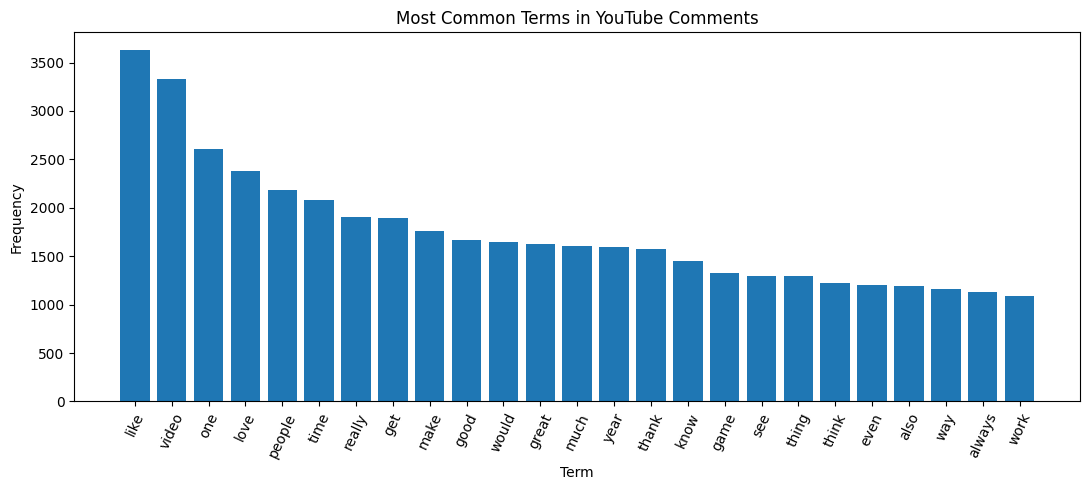

In [8]:
words = " ".join(df["clean_comment"]).split()
top_words = pd.DataFrame(Counter(words).most_common(25), columns=["Term","Frequency"])
display(top_words)

plt.figure(figsize=(11,5))
plt.bar(top_words["Term"], top_words["Frequency"])
plt.title("Most Common Terms in YouTube Comments")
plt.xlabel("Term"); plt.ylabel("Frequency")
plt.xticks(rotation=65); plt.tight_layout(); plt.show()

## 7. Positive and Negative Viewer Interests

In [9]:
for sentiment in df["sentiment"].unique():
    words = " ".join(df.loc[df["sentiment"]==sentiment,"clean_comment"]).split()
    temp = pd.DataFrame(Counter(words).most_common(15), columns=["Term","Frequency"])
    print("\nTop terms in", sentiment, "comments")
    display(temp)


Top terms in Negative comments


,Term,Frequency
0,people,811
1,like,704
2,one,501
3,get,451
4,would,411
5,even,381
6,time,368
7,know,361
8,think,317
9,make,315



Top terms in Positive comments


,Term,Frequency
0,video,2680
1,like,2351
2,love,2165
3,one,1617
4,thank,1495
5,great,1474
6,really,1462
7,good,1345
8,time,1279
9,much,1262



Top terms in Neutral comments


,Term,Frequency
0,like,576
1,one,485
2,time,431
3,que,423
4,get,365
5,video,356
6,know,337
7,would,331
8,make,308
9,year,289


## 8. TF-IDF Feature Extraction

In [10]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_comment"], df["sentiment"],
    test_size=0.20, random_state=42, stratify=df["sentiment"]
)
vectorizer = TfidfVectorizer(stop_words="english", max_features=12000, ngram_range=(1,2), min_df=2)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)
print(X_train.shape, X_test.shape)

(18279, 12000) (4570, 12000)


## 9. Multinomial Naive Bayes

In [11]:
nb = MultinomialNB().fit(X_train,y_train)
nb_pred, nb_acc, nb_pre, nb_rec, nb_f1 = evaluate_model("Multinomial NB",nb,X_test,y_test)

Multinomial NB Accuracy: 68.69%
Weighted Precision: 71.31%
Weighted Recall: 68.69%
Weighted F1: 63.10%
              precision    recall  f1-score   support

    Negative       0.80      0.31      0.45       897
     Neutral       0.75      0.20      0.31       901
    Positive       0.67      0.97      0.79      2772

    accuracy                           0.69      4570
   macro avg       0.74      0.49      0.52      4570
weighted avg       0.71      0.69      0.63      4570



## 10. Logistic Regression

In [12]:
lr = LogisticRegression(max_iter=1000).fit(X_train,y_train)
lr_pred, lr_acc, lr_pre, lr_rec, lr_f1 = evaluate_model("Logistic Regression",lr,X_test,y_test)

Logistic Regression Accuracy: 75.40%
Weighted Precision: 74.35%
Weighted Recall: 75.40%
Weighted F1: 74.10%
              precision    recall  f1-score   support

    Negative       0.72      0.53      0.61       897
     Neutral       0.63      0.49      0.55       901
    Positive       0.79      0.91      0.85      2772

    accuracy                           0.75      4570
   macro avg       0.71      0.64      0.67      4570
weighted avg       0.74      0.75      0.74      4570



## 11. GridSearchCV

In [13]:
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    {"C":[0.5,1.0,2.0],"solver":["liblinear"]},
    cv=3, scoring="f1_weighted", n_jobs=-1
)
grid.fit(X_train,y_train)
print("Best parameters:",grid.best_params_)
best_model = grid.best_estimator_
grid_pred, grid_acc, grid_pre, grid_rec, grid_f1 = evaluate_model(
    "Tuned Logistic Regression",best_model,X_test,y_test
)

Best parameters: {'C': 2.0, 'solver': 'liblinear'}
Tuned Logistic Regression Accuracy: 75.75%
Weighted Precision: 74.68%
Weighted Recall: 75.75%
Weighted F1: 74.56%
              precision    recall  f1-score   support

    Negative       0.72      0.55      0.62       897
     Neutral       0.63      0.49      0.55       901
    Positive       0.79      0.91      0.85      2772

    accuracy                           0.76      4570
   macro avg       0.71      0.65      0.67      4570
weighted avg       0.75      0.76      0.75      4570



## 12. Model Comparison

,Model,Accuracy (%),Weighted F1 (%)
0,Multinomial NB,68.69,63.10
1,Logistic Regression,75.40,74.10
2,Tuned Logistic Regression,75.75,74.56


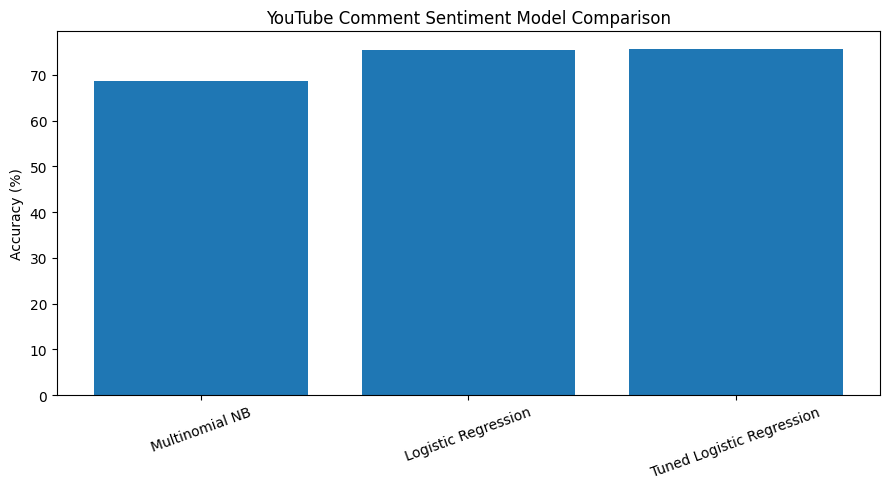

In [14]:
comparison = pd.DataFrame({
    "Model":["Multinomial NB","Logistic Regression","Tuned Logistic Regression"],
    "Accuracy (%)":[nb_acc*100,lr_acc*100,grid_acc*100],
    "Weighted F1 (%)":[nb_f1*100,lr_f1*100,grid_f1*100]
})
display(comparison.round(2))
plt.figure(figsize=(9,5))
plt.bar(comparison["Model"],comparison["Accuracy (%)"])
plt.title("YouTube Comment Sentiment Model Comparison")
plt.ylabel("Accuracy (%)"); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

## 13. Confusion Matrix

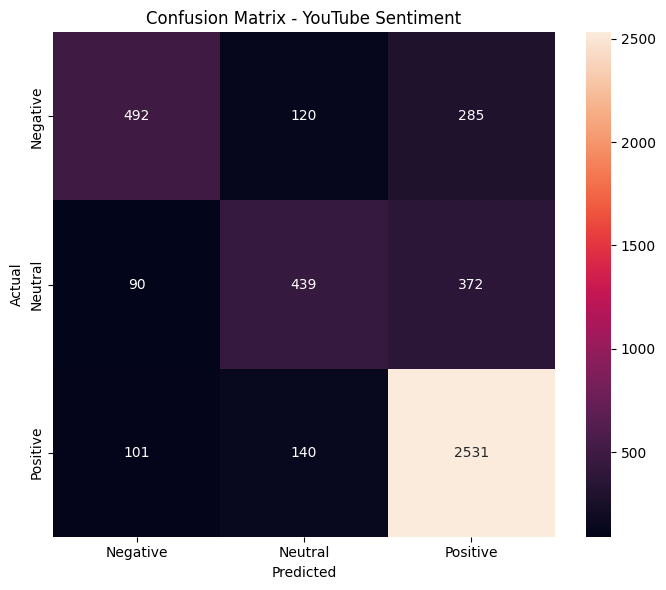

In [15]:
cm = confusion_matrix(y_test,grid_pred,labels=best_model.classes_)
plt.figure(figsize=(7,6))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=best_model.classes_,yticklabels=best_model.classes_)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - YouTube Sentiment")
plt.tight_layout(); plt.show()

## 14. Custom Comment Prediction

In [16]:
def predict_comment(comment):
    cleaned = preprocess_text(comment)
    return best_model.predict(vectorizer.transform([cleaned]))[0]

print(predict_comment("This video is amazing and very helpful!"))
print(predict_comment("This video was boring and not useful at all."))

Positive
Positive


## 15. Audience Analysis Report

In [17]:
print("YOUTUBE AUDIENCE ANALYSIS")
print("-------------------------")
print("Total comments analyzed:",len(df))
print("Most common sentiment:",df["sentiment"].value_counts().idxmax())
print("Most common terms:",", ".join(top_words.head(10)["Term"]))
for s in ["Positive","Negative"]:
    if s in df["sentiment"].values:
        print(f"{s} comments: {(df['sentiment']==s).mean()*100:.2f}%")

YOUTUBE AUDIENCE ANALYSIS
-------------------------
Total comments analyzed: 22849
Most common sentiment: Positive
Most common terms: like, video, one, love, people, time, really, get, make, good
Positive comments: 60.65%
Negative comments: 19.64%


## 16. Conclusion

The project uses NLP preprocessing, TF-IDF and machine-learning classification to analyze YouTube comments. Viewer interests are explored through frequent terms, while sentiment visualizations summarize audience reactions.

All evaluation metrics are generated from the actual dataset when the notebook is executed.